# Player Tracking in Sports - Multi-View Tracking and 3D Reconstruction

## Imports

In [1]:
from src.utils.video import open_video, get_frames, save_video
from src.tracking.motion_detection import MOG2_motion_detection, refine_blobs
from src.tracking.image_processing import opening_closing, remove_reflections
from src.utils.visualization import show_image

import cv2

## Path Definitions

In [2]:
VIDEOS_DIR = "data/videos"

# Video definitions: each cam
CAMERAS = {
    "cam_13": {
        "video_path": "data/videos/out13.mp4",
    },
    "cam_2": {
        "video_path": "data/videos/out2.mp4",
    },
    "cam_4": {
        "video_path": "data/videos/out4.mp4",
    },
}

## Open Video and Read Frames

In [ ]:
# Currently just one camera
cap = open_video(CAMERAS["cam_13"]["video_path"])
frames_color, _ = get_frames(cap, max_frames=None)

# Release the video capture object to free resources
cap.release()

show_image(frames_color[0], title="Original Frame")

## Image Preprocessing

We first apply a Gaussian blur to reduce reflection and noise in the frames. This helps improve the performance of motion detection algorithms.

Then, we apply a custom function `remove_reflections` to further clean the frames by removing reflections and shadows that can interfere with motion detection.

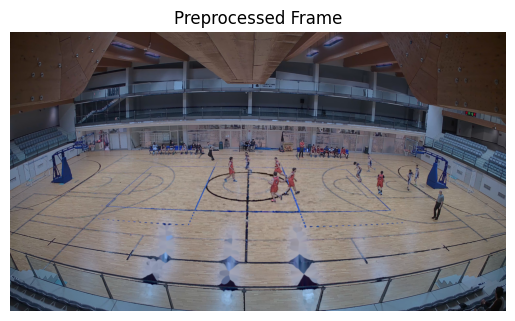

In [ ]:
# Function to remove reflections and shadows from the motion masks
refined_frames_color = remove_reflections([frames_color[0]], sat_threshold=80, val_threshold=180, inpaint_radius=5)

show_image(refined_frames_color[0], title="Preprocessed Frame")

## Motion Detection

### Mixture of Gaussians (MOG2) Background Subtraction

In [5]:
# Parameters for MOG2 motion detection
learning_rate = -1 # Use default learning rate (auto-adaptive)
history_length = 1500
var_threshold = 16
detect_shadows = False

# Compute motion masks using MOG2
masks = MOG2_motion_detection(frames_color, learning_rate, history_length, var_threshold, detect_shadows)

### Motion Video Post-processing

- Apply morphological operations to clean up the masks.
- Blob filtering to remove small noise blobs and keep only significant motion areas.

In [ ]:
# Morphological opening and closing to clean up the masks
opening_kernel_size = 7
closing_kernel_size = 7
masks = opening_closing(masks, opening_kernel_size=opening_kernel_size, closing_kernel_size=closing_kernel_size)

# Blob filtering to remove small noise blobs and keep only significant motion areas
masks = refine_blobs(masks, min_area=200)

In [7]:
 # Save results as video
save_video(masks, "results/motion_detection/cam13/cam_13_mog2_masks.mp4")

Video saved successfully at: results/motion_detection/cam13/cam_13_mog2_masks.mp4


**Temporary** : Cam 13 — Region of Interest

In [8]:
# Adjust roi_y to find the right horizontal boundary for cam 13
roi_y = 300
frame = frames_color[0]  # Use the first frame for visualization
h, w, _ = frame.shape

cv2.line(frame, (0, roi_y), (w, roi_y), (255, 255, 255), 2)

array([[[14, 24, 35],
        [14, 24, 35],
        [14, 24, 35],
        ...,
        [ 5, 21, 36],
        [ 5, 21, 36],
        [ 5, 21, 36]],

       [[14, 24, 35],
        [14, 24, 35],
        [14, 24, 35],
        ...,
        [ 5, 21, 36],
        [ 5, 21, 36],
        [ 5, 21, 36]],

       [[14, 24, 35],
        [14, 24, 35],
        [14, 24, 35],
        ...,
        [ 5, 21, 36],
        [ 5, 21, 36],
        [ 5, 21, 36]],

       ...,

       [[83, 67, 57],
        [83, 67, 57],
        [83, 67, 57],
        ...,
        [22, 17, 10],
        [22, 17, 10],
        [22, 17, 10]],

       [[83, 67, 57],
        [83, 67, 57],
        [83, 67, 57],
        ...,
        [22, 17, 10],
        [22, 17, 10],
        [22, 17, 10]],

       [[83, 67, 57],
        [83, 67, 57],
        [83, 67, 57],
        ...,
        [22, 17, 10],
        [22, 17, 10],
        [22, 17, 10]]], shape=(2160, 3840, 3), dtype=uint8)